<a href="https://colab.research.google.com/github/nandhanapriya88-cyber/Computer-Vision/blob/main/detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

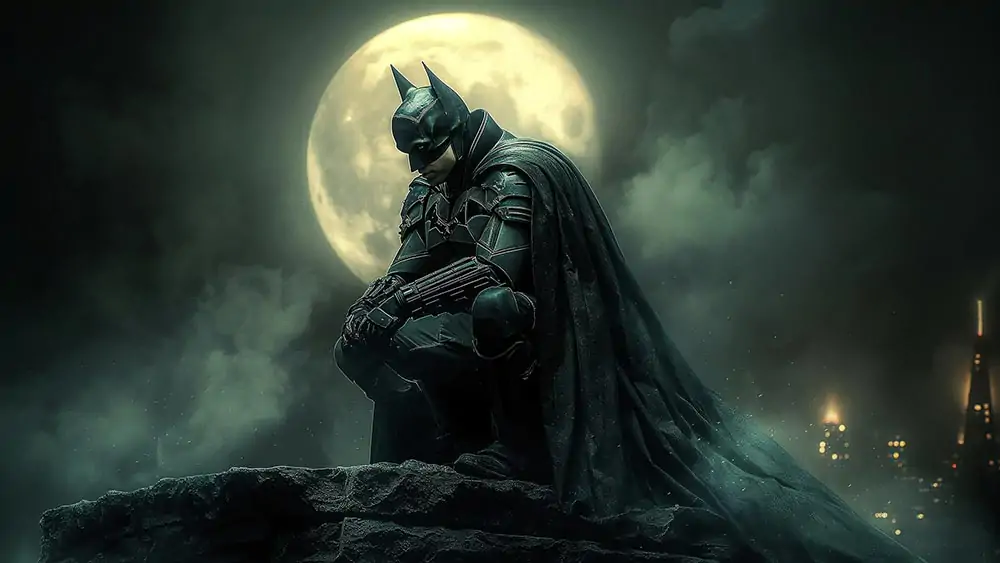

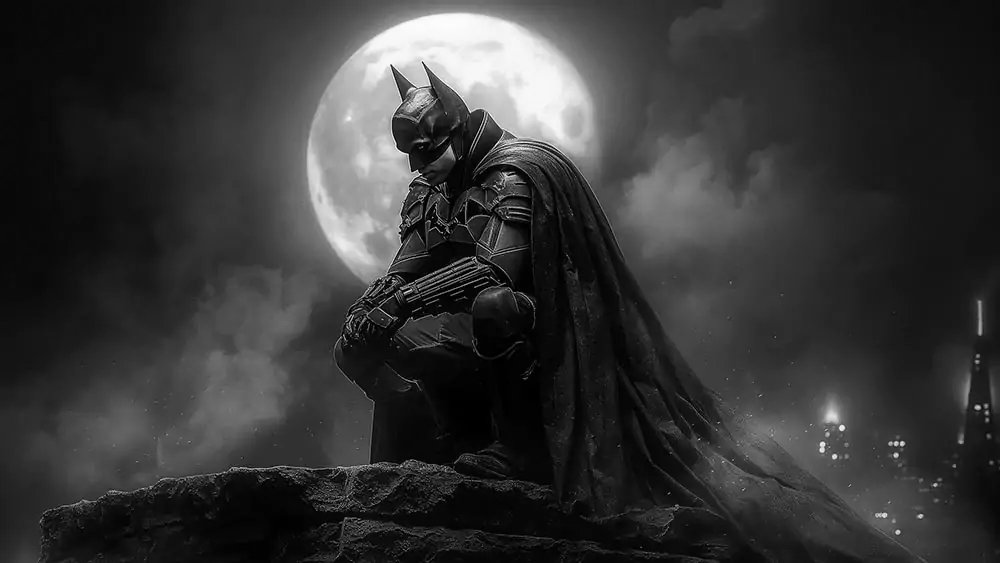

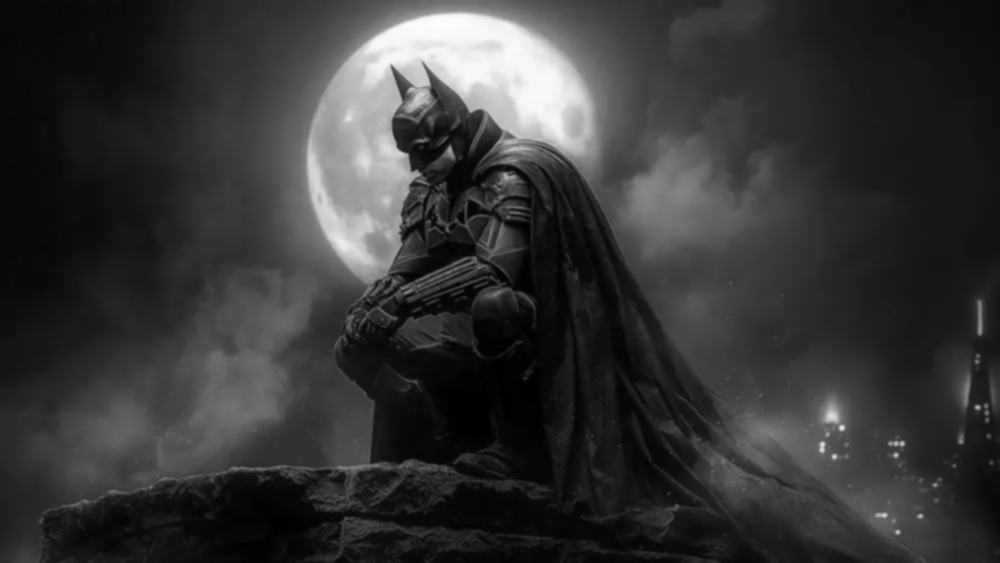

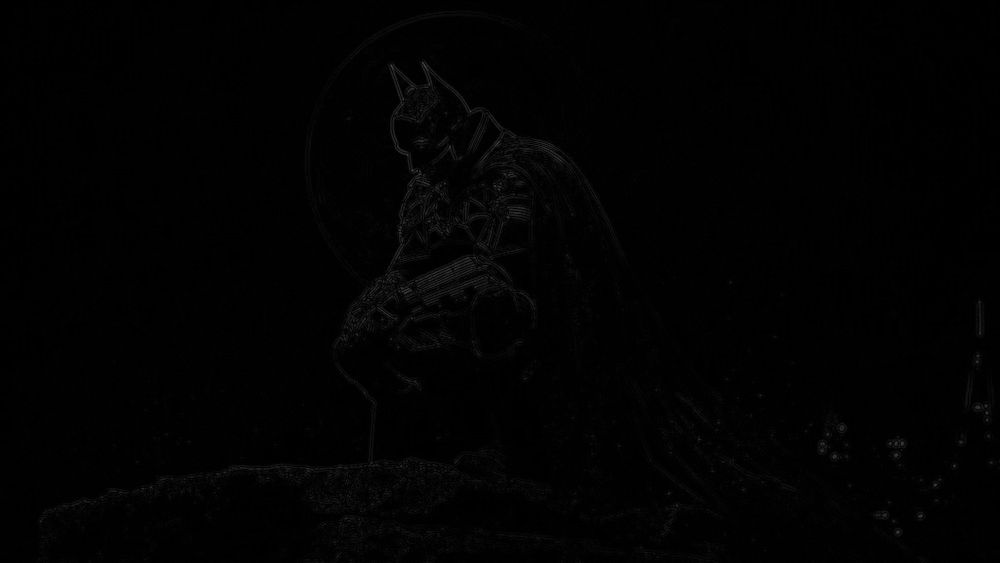

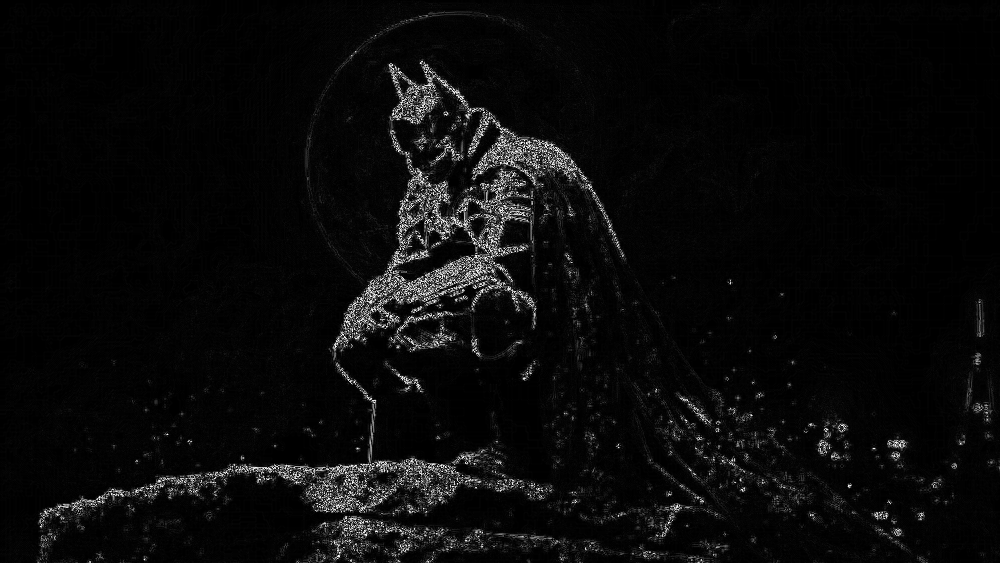

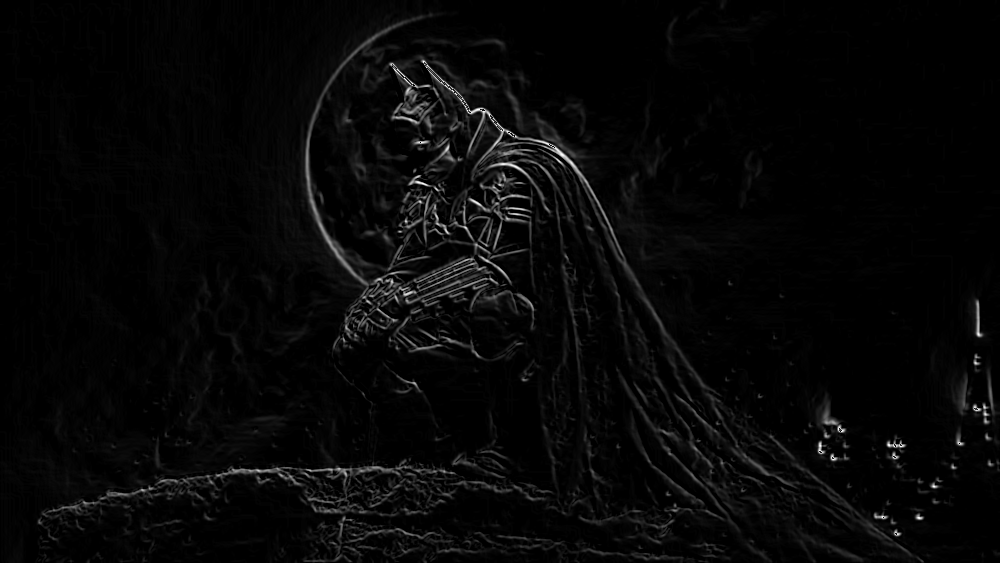

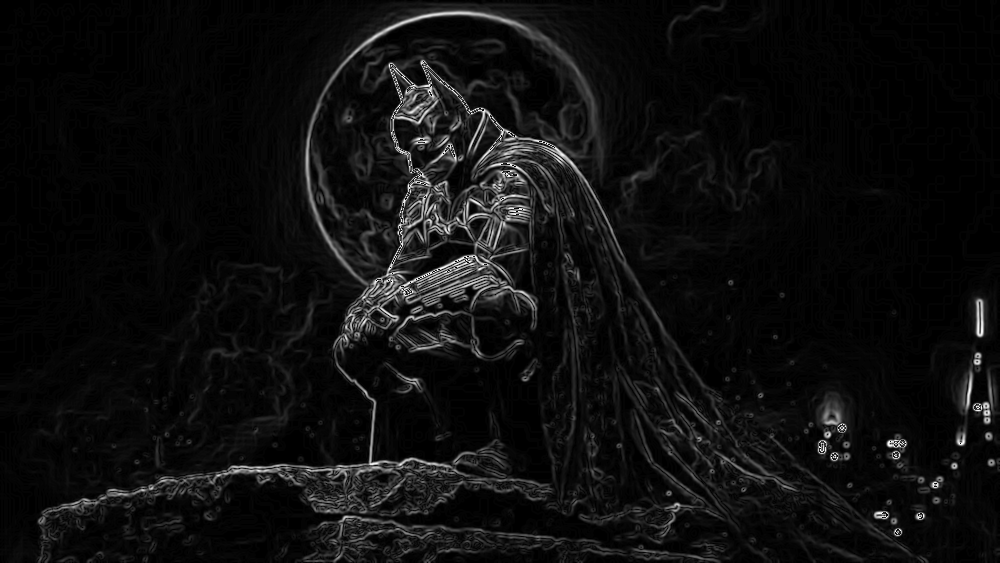

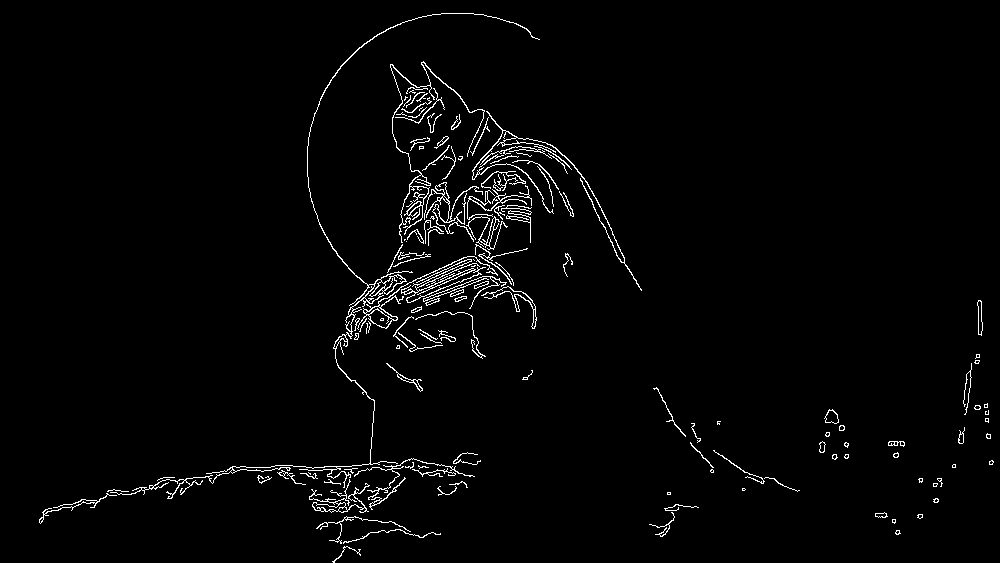

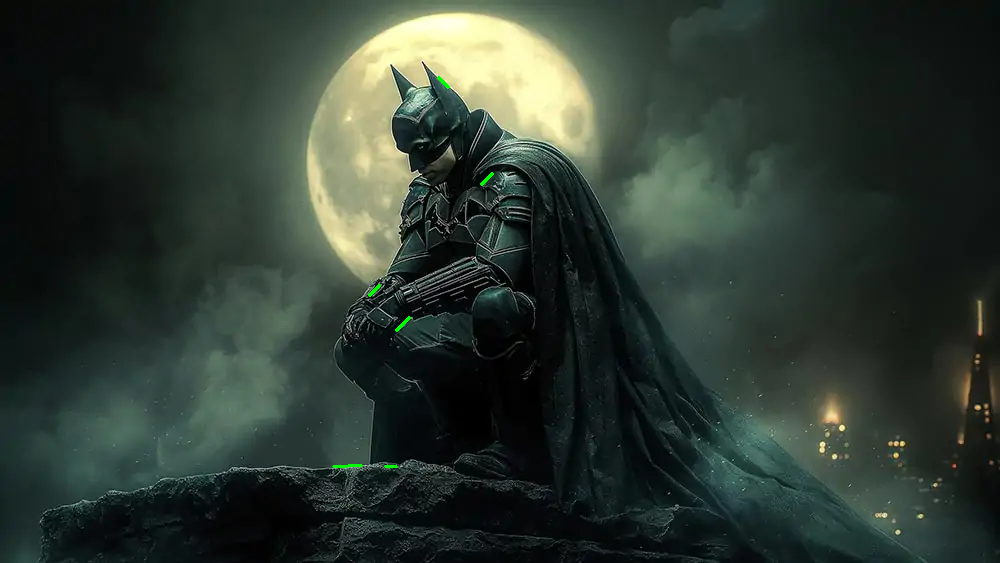

In [1]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# -------- Step 1: Image path --------
image_path = "/content/131.jpg.webp"   # uploaded file name
img = cv2.imread(image_path)

if img is None:
    print("Error: Image not found")
    exit()

cv2_imshow(img)

# -------- Step 2: Grayscale --------
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur_gray = cv2.GaussianBlur(gray, (5, 5), 0)

cv2_imshow(gray)
cv2_imshow(blur_gray)

# -------- Step 3: Point Detection --------
lap_gray = cv2.Laplacian(blur_gray, cv2.CV_64F)
lap_gray = np.uint8(np.absolute(lap_gray))
cv2_imshow(lap_gray)

b, g, r = cv2.split(img)
lap_rgb = np.sqrt(
    cv2.Laplacian(r, cv2.CV_64F)**2 +
    cv2.Laplacian(g, cv2.CV_64F)**2 +
    cv2.Laplacian(b, cv2.CV_64F)**2
)
lap_rgb = np.uint8(lap_rgb)
cv2_imshow(lap_rgb)

# -------- Step 4: Prewitt --------
px = np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
py = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])

prewitt_gray = cv2.filter2D(blur_gray, -1, px) + cv2.filter2D(blur_gray, -1, py)
cv2_imshow(prewitt_gray)

# -------- Step 5: Sobel --------
sx = cv2.Sobel(blur_gray, cv2.CV_64F, 1, 0)
sy = cv2.Sobel(blur_gray, cv2.CV_64F, 0, 1)
sobel_gray = np.uint8(cv2.magnitude(sx, sy))
cv2_imshow(sobel_gray)

# -------- Step 6: Line Detection --------
edges = cv2.Canny(blur_gray, 50, 150)
cv2_imshow(edges)

lines = cv2.HoughLinesP(edges, 1, np.pi/180, 100, 50, 10)
line_img = img.copy()

if lines is not None:
    for l in lines:
        x1,y1,x2,y2 = l[0]
        cv2.line(line_img, (x1,y1), (x2,y2), (0,255,0), 2)

cv2_imshow(line_img)

